# 📊 Analyse Complète des Données Amazon

**Auteur:** Équipe Data Analysis  
**Date:** 2026-02-10  
**Dataset:** amazon_final.csv  

---

## 📋 Table des Matières
1. [Chargement et Exploration des Données](#1-chargement)
2. [Nettoyage des Données](#2-nettoyage)
3. [Analyse Descriptive](#3-analyse-descriptive)
4. [Analyse des Prix](#4-analyse-prix)
5. [Analyse des Ratings et Reviews](#5-ratings-reviews)
6. [Analyse des Produits Prime](#6-prime)
7. [Analyse des Catégories de Produits](#7-categories)
8. [Visualisations Avancées](#8-visualisations)
9. [Insights et Recommandations](#9-insights)

---
## 1. Chargement et Exploration des Données 📥

In [3]:
import pandas as pd
# Chargement du dataset nettoyé
print("📂 Chargement du dataset nettoyé...\n")
df = pd.read_csv('amazon_data_clean.csv')

print("✅ Dataset nettoyé chargé avec succès!")
print(f"📊 Nombre de lignes: {len(df):,}")
print(f"📊 Nombre de colonnes: {len(df.columns)}")
print(f"\n📋 Colonnes disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

📂 Chargement du dataset nettoyé...

✅ Dataset nettoyé chargé avec succès!
📊 Nombre de lignes: 50,444
📊 Nombre de colonnes: 16

📋 Colonnes disponibles:
  1. title
  2. asin
  3. price
  4. currency
  5. rating
  6. reviews_count
  7. url
  8. image
  9. source_domain
  10. collected_at
  11. isPrime
  12. shippingMessage
  13. sponsoredAd
  14. bought_info_last_month
  15. price_clean
  16. price_numeric


In [4]:
df.head()

,title,asin,price,currency,rating,reviews_count,url,image,source_domain,collected_at,isPrime,shippingMessage,sponsoredAd,bought_info_last_month,price_clean,price_numeric
0,roku streaming stick hd 2025 — hd streaming de...,B0DXXYS4BJ,$15.99,$,4.7,12902,https://www.amazon.com/Roku-Streaming-Stick-HD...,https://m.media-amazon.com/images/I/71GUOcJCzS...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7 on $35 of items shipp...",False,10000,15.99,15.99
1,"garmin fēnix® 8 – 51 mm, amoled, sapphire, pre...",B0DD5QDZQ6,"$1,148.00",$,4.6,1956,https://www.amazon.com/Garmin-f%C4%93nix%C2%AE...,https://m.media-amazon.com/images/I/61we9NlBYl...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7Or fastest delivery We...",False,5,1148.00,1148.00
2,"a3 real-time translation earbuds, ai 66+ langu...",B0GCMKDKB7,$129.99,$,4.2,40,https://www.amazon.com/SoundAI-Translation-Hea...,https://m.media-amazon.com/images/I/51Nzw+B530...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7Or fastest delivery We...",False,44,129.99,129.99
3,surge protector power strip - hanycony 8 outle...,B092J8LPWR,$9.98,$,4.8,63978,https://www.amazon.com/Surge-Protector-Power-S...,https://m.media-amazon.com/images/I/61q9hmplGF...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7 on $35 of items shipp...",False,10000,9.98,9.98
4,snap circuits jr. sc-100 electronics explorati...,B00008BFZH,$32.99,$,4.8,28765,https://www.amazon.com/Snap-Circuits-SC-100-El...,https://m.media-amazon.com/images/I/91THy3rMlC...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7 on $35 of items shipp...",False,6000,32.99,32.99


---
## 📊 Métriques Clés du Dataset

In [ ]:
print("="*80)
print("📊 MÉTRIQUES PRINCIPALES DU DATASET AMAZON")
print("="*80)

# 1. Métriques générales
print("\n🔢 MÉTRIQUES GÉNÉRALES:")
print("-" * 80)
print(f"Nombre total de produits: {len(df):,}")
print(f"Nombre de produits uniques (ASIN): {df['asin'].nunique():,}")
print(f"Période de collecte: {df['collected_at'].min()} à {df['collected_at'].max()}")

# 2. Métriques de prix
print("\n💰 MÉTRIQUES DE PRIX:")
print("-" * 80)
print(f"Prix minimum: ${df['price_numeric'].min():.2f}")
print(f"Prix maximum: ${df['price_numeric'].max():,.2f}")
print(f"Prix moyen: ${df['price_numeric'].mean():.2f}")
print(f"Prix médian: ${df['price_numeric'].median():.2f}")
print(f"Écart-type des prix: ${df['price_numeric'].std():.2f}")

# 3. Métriques de qualité
print("\n⭐ MÉTRIQUES DE QUALITÉ:")
print("-" * 80)
print(f"Note moyenne: {df['rating'].mean():.2f}/5.00")
print(f"Note médiane: {df['rating'].median():.2f}/5.00")
print(f"Nombre moyen de reviews: {df['reviews_count'].mean():,.0f}")
print(f"Nombre médian de reviews: {df['reviews_count'].median():,.0f}")
print(f"Produits avec 5 étoiles: {(df['rating'] == 5.0).sum():,} ({(df['rating'] == 5.0).sum() / len(df) * 100:.1f}%)")
print(f"Produits avec 4+ étoiles: {(df['rating'] >= 4.0).sum():,} ({(df['rating'] >= 4.0).sum() / len(df) * 100:.1f}%)")

# 4. Métriques Prime
print("\n🚀 MÉTRIQUES PRIME:")
print("-" * 80)
prime_count = df['isPrime'].sum()
print(f"Produits Prime: {prime_count:,} ({prime_count / len(df) * 100:.1f}%)")
print(f"Produits Non-Prime: {(~df['isPrime']).sum():,} ({(~df['isPrime']).sum() / len(df) * 100:.1f}%)")
print(f"Prix moyen Prime: ${df[df['isPrime']]['price_numeric'].mean():.2f}")
print(f"Prix moyen Non-Prime: ${df[~df['isPrime']]['price_numeric'].mean():.2f}")

# 5. Métriques de popularité
print("\n🔥 MÉTRIQUES DE POPULARITÉ:")
print("-" * 80)
print(f"Achats moyens/mois: {df['bought_info_last_month'].mean():,.0f}")
print(f"Achats médians/mois: {df['bought_info_last_month'].median():,.0f}")
print(f"Produits avec 1000+ achats/mois: {(df['bought_info_last_month'] >= 1000).sum():,}")
print(f"Produits avec 10000+ achats/mois: {(df['bought_info_last_month'] >= 10000).sum():,}")

# 6. Métriques de qualité des données
print("\n✅ QUALITÉ DES DONNÉES:")
print("-" * 80)
print(f"Valeurs manquantes totales: {df.isnull().sum().sum():,}")
print(f"Doublons: {df.duplicated().sum():,}")
print(f"Produits avec prix $0.00: {(df['price_numeric'] == 0).sum():,}")
print(f"Taux de complétude: {(1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%")

print("\n" + "="*80)

📊 MÉTRIQUES PRINCIPALES DU DATASET AMAZON

🔢 MÉTRIQUES GÉNÉRALES:
--------------------------------------------------------------------------------
Nombre total de produits: 50,444
Nombre de produits uniques (ASIN): 50,444
Période de collecte: 2026-02-02 18:59:19.337253 à 2026-02-03 06:15:21.222176

💰 MÉTRIQUES DE PRIX:
--------------------------------------------------------------------------------
Prix minimum: $0.99
Prix maximum: $399,800.00
Prix moyen: $76.73
Prix médian: $24.99
Écart-type des prix: $1838.52

⭐ MÉTRIQUES DE QUALITÉ:
--------------------------------------------------------------------------------
Note moyenne: 4.48/5.00
Note médiane: 4.50/5.00
Nombre moyen de reviews: 4,929
Nombre médian de reviews: 762
Produits avec 5 étoiles: 889 (1.8%)
Produits avec 4+ étoiles: 48,310 (95.8%)

🚀 MÉTRIQUES PRIME:
--------------------------------------------------------------------------------
Produits Prime: 292 (0.6%)
Produits Non-Prime: 50,152 (99.4%)
Prix moyen Prime: $47.19
Pri

In [ ]:
# Distribution des prix par tranches
print("\n💰 DISTRIBUTION DES PRIX PAR TRANCHES:")
print("-" * 80)

price_ranges = [
    (0, 10, "$0-$10"),
    (10, 25, "$10-$25"),
    (25, 50, "$25-$50"),
    (50, 100, "$50-$100"),
    (100, 500, "$100-$500"),
    (500, float('inf'), "$500+")
]

for min_price, max_price, label in price_ranges:
    count = ((df['price_numeric'] >= min_price) & (df['price_numeric'] < max_price)).sum()
    percentage = count / len(df) * 100
    print(f"{label:12} : {count:6,} produits ({percentage:5.1f}%)")


💰 DISTRIBUTION DES PRIX PAR TRANCHES:
--------------------------------------------------------------------------------
$0-$10       :  8,247 produits ( 16.3%)
$10-$25      : 17,156 produits ( 34.0%)
$25-$50      : 12,868 produits ( 25.5%)
$50-$100     :  5,735 produits ( 11.4%)
$100-$500    :  4,965 produits (  9.8%)
$500+        :    717 produits (  1.4%)


In [ ]:
# Top 10 des produits les plus populaires
print("\n🏆 TOP 10 DES PRODUITS LES PLUS POPULAIRES (par achats):")
print("="*80)

top_10 = df.nlargest(10, 'bought_info_last_month')[['title', 'price', 'rating', 'reviews_count', 'bought_info_last_month']]
for idx, row in top_10.iterrows():
    print(f"\n{row.name + 1}. {row['title'][:60]}...")
    print(f"   Prix: {row['price']} | Note: {row['rating']}/5 | Reviews: {row['reviews_count']:,} | Achats: {row['bought_info_last_month']:,}")


🏆 TOP 10 DES PRODUITS LES PLUS POPULAIRES (par achats):

1943. oxiclean odor blasters versatile odor and laundry stain remo...
   Prix: $11.78 | Note: 4.8/5 | Reviews: 44,144 | Achats: 100,000

2029. garden of life once daily dr. formulated probiotics for wome...
   Prix: $29.73 | Note: 4.6/5 | Reviews: 59,070 | Achats: 100,000

3375. the ordinary niacinamide 10% + zinc 1%, smoothing serum for ...
   Prix: $6.00 | Note: 4.7/5 | Reviews: 47,492 | Achats: 100,000

3379. medicube toner pads zero pore pad 2.0 | dual-textured facial...
   Prix: $18.90 | Note: 4.6/5 | Reviews: 23,370 | Achats: 100,000

3386. eos shea better body lotion vanilla cashmere, 24-hour moistu...
   Prix: $9.97 | Note: 4.7/5 | Reviews: 61,558 | Achats: 100,000

3389. medicube wrapping mask collagen overnight peel off facial ma...
   Prix: $19.00 | Note: 4.5/5 | Reviews: 16,134 | Achats: 100,000

3392. biodance bio-collagen real deep mask, hydrating overnight hy...
   Prix: $19.00 | Note: 4.5/5 | Reviews: 34,362 | Ac

In [ ]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Bibliothèques chargées avec succès!")

✅ Bibliothèques chargées avec succès!


In [ ]:
# Chargement des données
print("📂 Chargement du fichier CSV...")
df = pd.read_csv('amazon_final.csv', on_bad_lines='skip', encoding='utf-8')

print(f"\n✅ Données chargées avec succès!")
print(f"📊 Nombre de lignes: {len(df):,}")
print(f"📊 Nombre de colonnes: {len(df.columns)}")
print(f"\n📋 Colonnes disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

📂 Chargement du fichier CSV...

✅ Données chargées avec succès!
📊 Nombre de lignes: 50,444
📊 Nombre de colonnes: 14

📋 Colonnes disponibles:
  1. title
  2. asin
  3. price
  4. currency
  5. rating
  6. reviews_count
  7. url
  8. image
  9. source_domain
  10. collected_at
  11. isPrime
  12. shippingMessage
  13. sponsoredAd
  14. bought_info_last_month


In [ ]:
# Aperçu des premières lignes
print("👀 Aperçu des 5 premières lignes:\n")
df.head()

👀 Aperçu des 5 premières lignes:



,title,asin,price,currency,rating,reviews_count,url,image,source_domain,collected_at,isPrime,shippingMessage,sponsoredAd,bought_info_last_month
0,roku streaming stick hd 2025 — hd streaming de...,B0DXXYS4BJ,$15.99,$,4.70,12902,https://www.amazon.com/Roku-Streaming-Stick-HD...,https://m.media-amazon.com/images/I/71GUOcJCzS...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7 on $35 of items shipp...",False,10000
1,"garmin fēnix® 8 – 51 mm, amoled, sapphire, pre...",B0DD5QDZQ6,"$1,148.00",$,4.60,1956,https://www.amazon.com/Garmin-f%C4%93nix%C2%AE...,https://m.media-amazon.com/images/I/61we9NlBYl...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7Or fastest delivery We...",False,5
2,"a3 real-time translation earbuds, ai 66+ langu...",B0GCMKDKB7,$129.99,$,4.20,40,https://www.amazon.com/SoundAI-Translation-Hea...,https://m.media-amazon.com/images/I/51Nzw+B530...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7Or fastest delivery We...",False,44
3,surge protector power strip - hanycony 8 outle...,B092J8LPWR,$9.98,$,4.80,63978,https://www.amazon.com/Surge-Protector-Power-S...,https://m.media-amazon.com/images/I/61q9hmplGF...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7 on $35 of items shipp...",False,10000
4,snap circuits jr. sc-100 electronics explorati...,B00008BFZH,$32.99,$,4.80,28765,https://www.amazon.com/Snap-Circuits-SC-100-El...,https://m.media-amazon.com/images/I/91THy3rMlC...,amazon.com,2026-02-02 18:59:19.337253,False,"FREE delivery Sat, Feb 7 on $35 of items shipp...",False,6000


In [ ]:
# Informations sur le dataset
print("ℹ️ Informations sur le dataset:\n")
df.info()

ℹ️ Informations sur le dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50444 entries, 0 to 50443
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   50444 non-null  object 
 1   asin                    50444 non-null  object 
 2   price                   50444 non-null  object 
 3   currency                50441 non-null  object 
 4   rating                  50444 non-null  float64
 5   reviews_count           50444 non-null  int64  
 6   url                     50444 non-null  object 
 7   image                   50444 non-null  object 
 8   source_domain           50444 non-null  object 
 9   collected_at            50444 non-null  object 
 10  isPrime                 50444 non-null  bool   
 11  shippingMessage         50444 non-null  object 
 12  sponsoredAd             50444 non-null  bool   
 13  bought_info_last_month  50444 non-null  int64  
dtypes: bo

In [ ]:
# Statistiques descriptives
print("📈 Statistiques descriptives:\n")
df.describe()

📈 Statistiques descriptives:



,rating,reviews_count,bought_info_last_month
count,50444.00,50444.00,50444.00
mean,4.48,4929.43,1490.55
std,0.29,17008.77,5358.68
min,1.00,1.00,5.00
25%,4.40,143.00,49.00
50%,4.50,762.00,200.00
75%,4.70,3404.00,1000.00
max,5.00,899439.00,100000.00


---
## 2. Nettoyage des Données 🧹

🔍 Analyse des valeurs manquantes:

           Colonne  Valeurs Manquantes  Pourcentage (%)
currency  currency                   3             0.01


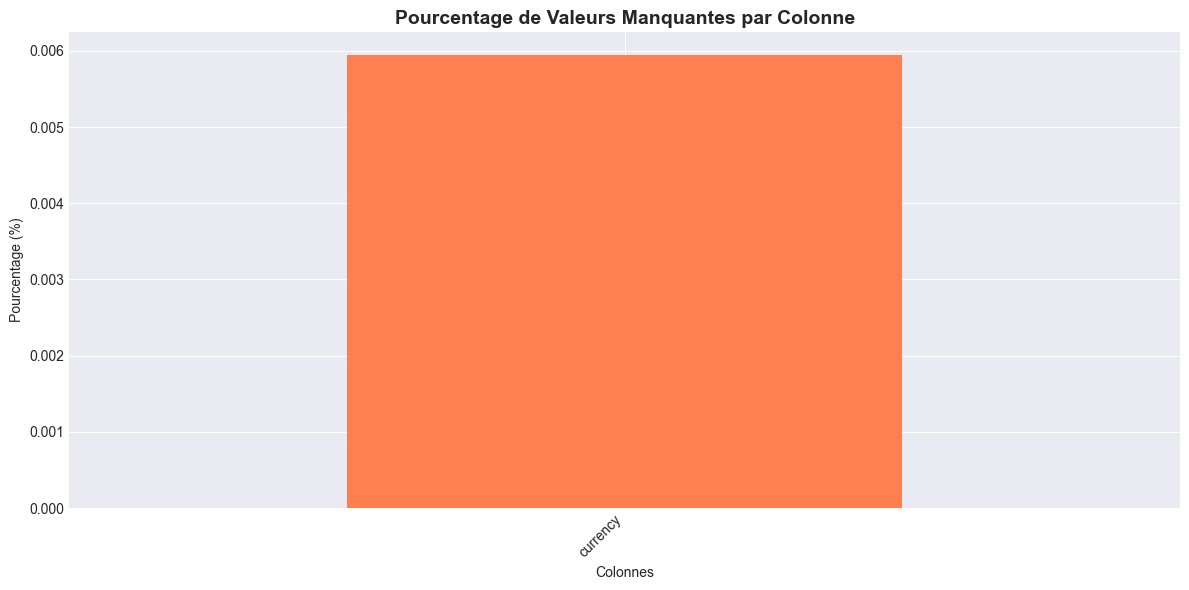

In [ ]:
# Vérification des valeurs manquantes
print("🔍 Analyse des valeurs manquantes:\n")
missing_data = pd.DataFrame({
    'Colonne': df.columns,
    'Valeurs Manquantes': df.isnull().sum(),
    'Pourcentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Valeurs Manquantes', ascending=False)

print(missing_data[missing_data['Valeurs Manquantes'] > 0])

# Visualisation
plt.figure(figsize=(12, 6))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
if len(missing_pct) > 0:
    missing_pct.plot(kind='bar', color='coral')
    plt.title('Pourcentage de Valeurs Manquantes par Colonne', fontsize=14, fontweight='bold')
    plt.xlabel('Colonnes')
    plt.ylabel('Pourcentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("✅ Aucune valeur manquante détectée!")

In [ ]:
# Nettoyage des prix
print("💰 Nettoyage de la colonne 'price'...\n")

# Conversion des prix en numérique
df['price_clean'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').str.strip()
df['price_numeric'] = pd.to_numeric(df['price_clean'], errors='coerce')

# Statistiques sur les prix
print(f"Prix minimum: ${df['price_numeric'].min():.2f}")
print(f"Prix maximum: ${df['price_numeric'].max():.2f}")
print(f"Prix moyen: ${df['price_numeric'].mean():.2f}")
print(f"Prix médian: ${df['price_numeric'].median():.2f}")

💰 Nettoyage de la colonne 'price'...

Prix minimum: $0.00
Prix maximum: $399800.00
Prix moyen: $76.71
Prix médian: $24.99


In [ ]:
# Conversion de la colonne collected_at en datetime
print("📅 Conversion de la colonne 'collected_at'...\n")
df['collected_at'] = pd.to_datetime(df['collected_at'], errors='coerce')
df['date'] = df['collected_at'].dt.date
df['hour'] = df['collected_at'].dt.hour

print(f"Période de collecte: {df['collected_at'].min()} à {df['collected_at'].max()}")

📅 Conversion de la colonne 'collected_at'...

Période de collecte: 2026-02-02 18:59:19.337253 à 2026-02-03 06:15:21.222176


In [ ]:
# Nettoyage de bought_info_last_month
print("🛒 Nettoyage de 'bought_info_last_month'...\n")
df['bought_last_month'] = pd.to_numeric(df['bought_info_last_month'], errors='coerce')

print(f"Produits avec info d'achat: {df['bought_last_month'].notna().sum():,}")
print(f"Total d'achats enregistrés: {df['bought_last_month'].sum():,.0f}")

🛒 Nettoyage de 'bought_info_last_month'...

Produits avec info d'achat: 50,444
Total d'achats enregistrés: 75,189,180


---
## 3. Analyse Descriptive 📊

In [ ]:
# Vue d'ensemble du dataset
print("="*60)
print("📊 VUE D'ENSEMBLE DU DATASET")
print("="*60)

print(f"\n📦 PRODUITS:")
print(f"  • Total de produits: {len(df):,}")
print(f"  • Produits uniques (ASIN): {df['asin'].nunique():,}")
print(f"  • Produits Prime: {df['isPrime'].sum():,} ({df['isPrime'].sum()/len(df)*100:.1f}%)")
print(f"  • Produits sponsorisés: {df['sponsoredAd'].sum():,} ({df['sponsoredAd'].sum()/len(df)*100:.1f}%)")

print(f"\n💰 PRIX:")
print(f"  • Prix moyen: ${df['price_numeric'].mean():.2f}")
print(f"  • Prix médian: ${df['price_numeric'].median():.2f}")
print(f"  • Écart-type: ${df['price_numeric'].std():.2f}")

print(f"\n⭐ RATINGS & REVIEWS:")
print(f"  • Rating moyen: {df['rating'].mean():.2f}/5")
print(f"  • Nombre moyen de reviews: {df['reviews_count'].mean():,.0f}")
print(f"  • Produit le plus reviewé: {df['reviews_count'].max():,} reviews")

📊 VUE D'ENSEMBLE DU DATASET

📦 PRODUITS:
  • Total de produits: 50,444
  • Produits uniques (ASIN): 50,444
  • Produits Prime: 292 (0.6%)
  • Produits sponsorisés: 2,681 (5.3%)

💰 PRIX:
  • Prix moyen: $76.71
  • Prix médian: $24.99
  • Écart-type: $1838.52

⭐ RATINGS & REVIEWS:
  • Rating moyen: 4.48/5
  • Nombre moyen de reviews: 4,929
  • Produit le plus reviewé: 899,439 reviews


---
## 4. Analyse des Prix 💰

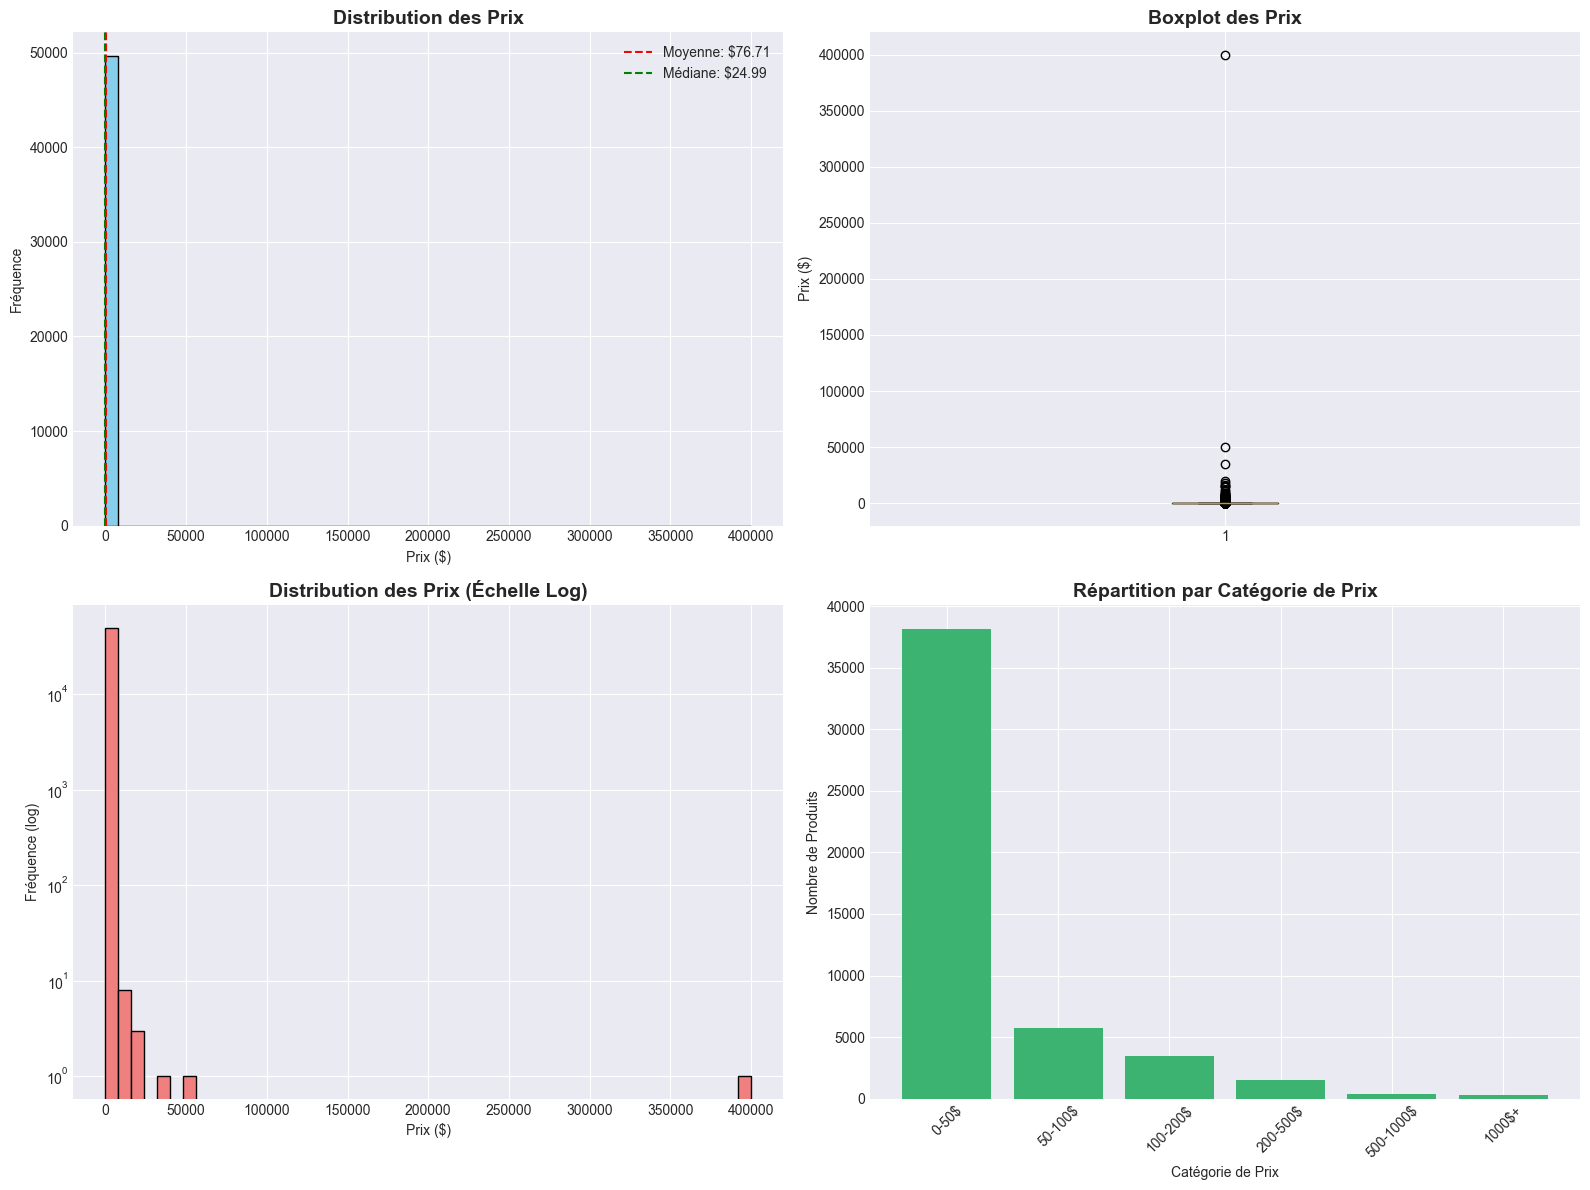

In [ ]:
# Distribution des prix
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogramme des prix
axes[0, 0].hist(df['price_numeric'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution des Prix', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Prix ($)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(df['price_numeric'].mean(), color='red', linestyle='--', label=f"Moyenne: ${df['price_numeric'].mean():.2f}")
axes[0, 0].axvline(df['price_numeric'].median(), color='green', linestyle='--', label=f"Médiane: ${df['price_numeric'].median():.2f}")
axes[0, 0].legend()

# Boxplot des prix
axes[0, 1].boxplot(df['price_numeric'].dropna(), vert=True)
axes[0, 1].set_title('Boxplot des Prix', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Prix ($)')

# Distribution des prix (log scale)
axes[1, 0].hist(df['price_numeric'].dropna(), bins=50, color='lightcoral', edgecolor='black')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Distribution des Prix (Échelle Log)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Prix ($)')
axes[1, 0].set_ylabel('Fréquence (log)')

# Catégories de prix
price_categories = pd.cut(df['price_numeric'], bins=[0, 50, 100, 200, 500, 1000, 5000], 
                          labels=['0-50$', '50-100$', '100-200$', '200-500$', '500-1000$', '1000$+'])
price_cat_counts = price_categories.value_counts().sort_index()
axes[1, 1].bar(range(len(price_cat_counts)), price_cat_counts.values, color='mediumseagreen')
axes[1, 1].set_xticks(range(len(price_cat_counts)))
axes[1, 1].set_xticklabels(price_cat_counts.index, rotation=45)
axes[1, 1].set_title('Répartition par Catégorie de Prix', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Catégorie de Prix')
axes[1, 1].set_ylabel('Nombre de Produits')

plt.tight_layout()
plt.show()

In [ ]:
# Top 10 produits les plus chers
print("💎 TOP 10 PRODUITS LES PLUS CHERS:\n")
top_expensive = df.nlargest(10, 'price_numeric')[['title', 'price_numeric', 'rating', 'reviews_count']]
top_expensive.index = range(1, 11)
top_expensive

💎 TOP 10 PRODUITS LES PLUS CHERS:



,title,price_numeric,rating,reviews_count
1,honma beres 7s fuji limited edition golf club ...,399800.00,3.90,11
2,"stake yur claim is a western board game, 3-8 p...",50000.00,2.70,4
3,cleveland range inc. kgl-80 kettle,34598.00,4.50,18
4,"electric coffee maker stand, special productio...",19999.00,4.00,27
5,tube condensor microphone,17995.00,5.00,3
6,rolex oyster perpetual explorer ii steel mens ...,15995.00,4.60,5
7,shoe change stool simple door dressing shoe st...,15565.59,4.40,43
8,aqua dream 500 gallon black aquarium kit with ...,14999.99,4.20,47
9,dji dji matrice 4d with dji rc plus 2 enterpri...,13998.00,4.00,22
10,rolex mens stainless steel and platinum yachtm...,11995.00,4.70,29


In [ ]:
# Top 10 produits les moins chers
print("💵 TOP 10 PRODUITS LES MOINS CHERS:\n")
top_cheap = df[df['price_numeric'] > 0].nsmallest(10, 'price_numeric')[['title', 'price_numeric', 'rating', 'reviews_count']]
top_cheap.index = range(1, 11)
top_cheap

💵 TOP 10 PRODUITS LES MOINS CHERS:



,title,price_numeric,rating,reviews_count
1,blind,0.99,3.40,69
2,blind love,0.99,3.80,8
3,black and privileged,0.99,3.80,38
4,baby shark aquarium - little angel,0.99,4.30,23
5,life in a tide pool,0.99,4.10,24
6,"cap blackard marc with a c presents: ""the obsc...",0.99,3.80,46
7,fred p watkins find her keep her,0.99,4.30,31
8,"wet n wild eyeshadow brush, precision blending...",0.99,4.50,114041
9,tom's car wash,0.99,4.50,22
10,kid's car wash,0.99,4.00,1


---
## 5. Analyse des Ratings et Reviews ⭐

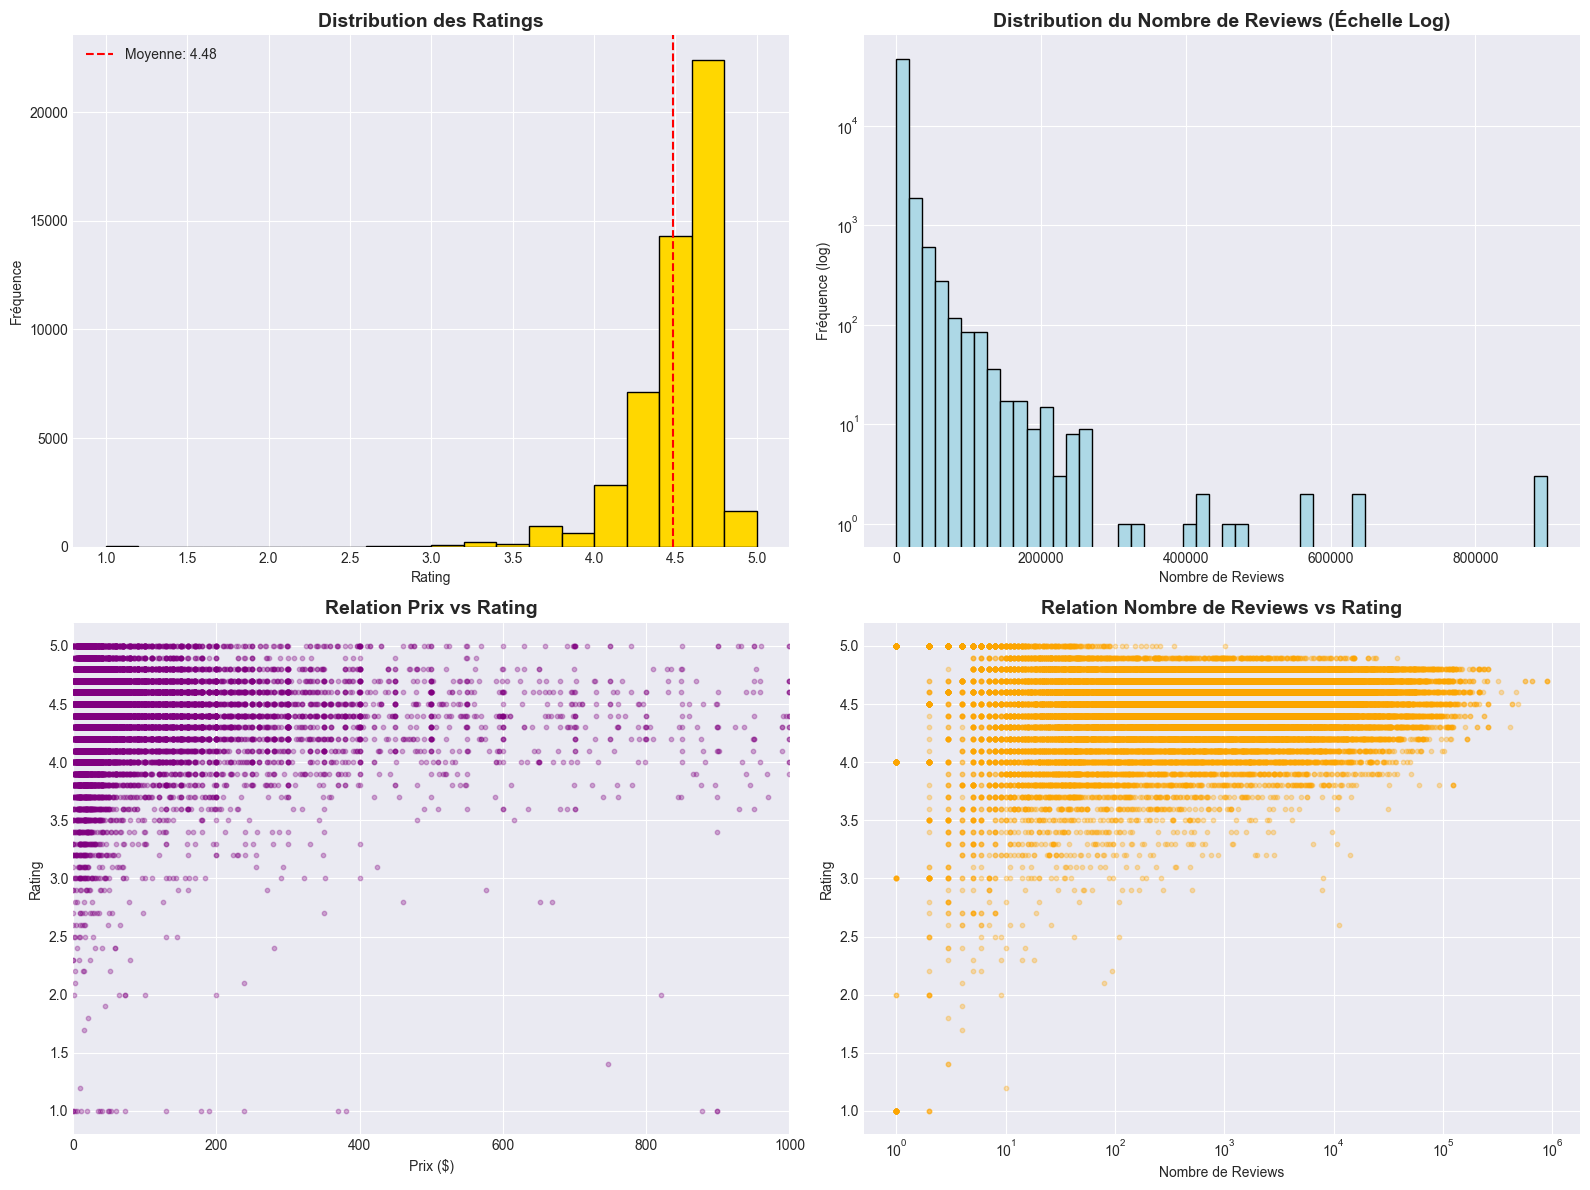

In [ ]:
# Analyse des ratings
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution des ratings
axes[0, 0].hist(df['rating'].dropna(), bins=20, color='gold', edgecolor='black')
axes[0, 0].set_title('Distribution des Ratings', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(df['rating'].mean(), color='red', linestyle='--', label=f"Moyenne: {df['rating'].mean():.2f}")
axes[0, 0].legend()

# Distribution des reviews (log scale)
axes[0, 1].hist(df['reviews_count'].dropna(), bins=50, color='lightblue', edgecolor='black')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribution du Nombre de Reviews (Échelle Log)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Nombre de Reviews')
axes[0, 1].set_ylabel('Fréquence (log)')

# Relation Prix vs Rating
axes[1, 0].scatter(df['price_numeric'], df['rating'], alpha=0.3, s=10, color='purple')
axes[1, 0].set_title('Relation Prix vs Rating', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Prix ($)')
axes[1, 0].set_ylabel('Rating')
axes[1, 0].set_xlim(0, 1000)

# Relation Reviews vs Rating
axes[1, 1].scatter(df['reviews_count'], df['rating'], alpha=0.3, s=10, color='orange')
axes[1, 1].set_title('Relation Nombre de Reviews vs Rating', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Nombre de Reviews')
axes[1, 1].set_ylabel('Rating')
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# Top 10 produits les mieux notés (avec au moins 100 reviews)
print("🌟 TOP 10 PRODUITS LES MIEUX NOTÉS (min 100 reviews):\n")
top_rated = df[df['reviews_count'] >= 100].nlargest(10, 'rating')[['title', 'rating', 'reviews_count', 'price_numeric']]
top_rated.index = range(1, 11)
top_rated

🌟 TOP 10 PRODUITS LES MIEUX NOTÉS (min 100 reviews):



,title,rating,reviews_count,price_numeric
1,hybrid active noise cancelling bluetooth 6.0 h...,5.00,1012,69.97
2,"cervical neck pillow for pain relief, memory f...",5.00,125,39.99
3,"cervical neck pillow for pain relief, bed pill...",5.00,174,35.99
4,golabs 2-3 person camping tent w/ 9.5x8.5 ft c...,5.00,116,99.99
5,"air purifers for home, true hepa air purifier ...",5.00,218,24.99
6,squishmallows original 12in marvel spider-man ...,5.00,193,19.81
7,occiam mini lavalier microphone for iphone & a...,5.00,259,79.98
8,occiam active noise cancelling earbuds wireles...,5.00,349,99.98
9,"portable cordless car vacuum, 4-in-1 handheld ...",5.00,153,49.98
10,chubory a77 brushless motor drone with camera ...,5.00,239,99.99


In [ ]:
# Top 10 produits les plus reviewés
print("📝 TOP 10 PRODUITS LES PLUS REVIEWÉS:\n")
top_reviewed = df.nlargest(10, 'reviews_count')[['title', 'reviews_count', 'rating', 'price_numeric']]
top_reviewed.index = range(1, 11)
top_reviewed

📝 TOP 10 PRODUITS LES PLUS REVIEWÉS:



,title,reviews_count,rating,price_numeric
1,amazon basics 20-pack aa alkaline high-perform...,899439,4.70,8.83
2,amazon basics 48-pack aa alkaline high-perform...,899438,4.70,13.52
3,amazon basics 100-pack aa alkaline high-perfor...,899438,4.70,26.99
4,amazon basics aaa alkaline high-performance ba...,645834,4.70,29.99
5,amazon basics aaa alkaline high-performance ba...,645834,4.70,13.70
6,"amazon basics hdmi cable, 6ft, 4k@60hz, high-s...",560945,4.70,4.45
7,"amazon basics hdmi cable, 3-pack, 6ft, 4k@60hz...",560945,4.70,8.99
8,revlon one-step volumizer hair dryer and style...,483355,4.50,31.99
9,amazon basics lightweight super soft easy care...,464740,4.60,18.98
10,queen size 4 piece sheet set - comfy breathabl...,423959,4.50,21.24


🔗 MATRICE DE CORRÉLATION:



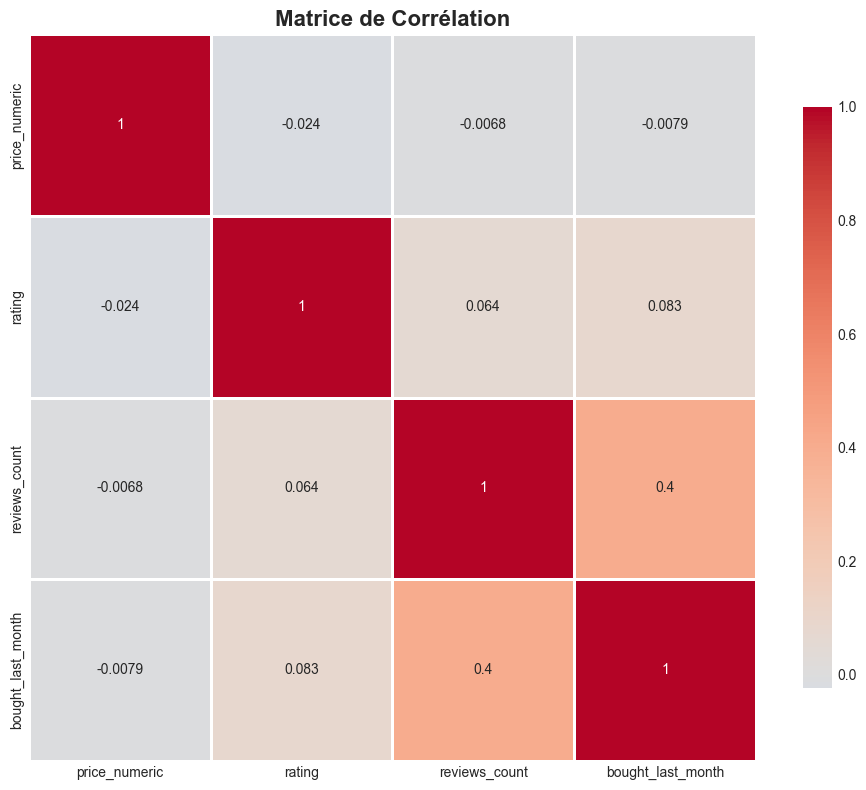

                   price_numeric  rating  reviews_count  bought_last_month
price_numeric               1.00   -0.02          -0.01              -0.01
rating                     -0.02    1.00           0.06               0.08
reviews_count              -0.01    0.06           1.00               0.40
bought_last_month          -0.01    0.08           0.40               1.00


In [ ]:
# Corrélation entre variables numériques
print("🔗 MATRICE DE CORRÉLATION:\n")
numeric_cols = ['price_numeric', 'rating', 'reviews_count', 'bought_last_month']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(correlation_matrix)

---
## 6. Analyse des Produits Prime 📦

In [ ]:
# Comparaison Prime vs Non-Prime
print("🔍 COMPARAISON PRIME vs NON-PRIME:\n")

prime_stats = df.groupby('isPrime').agg({
    'price_numeric': ['mean', 'median', 'std'],
    'rating': ['mean', 'median'],
    'reviews_count': ['mean', 'median'],
    'asin': 'count'
}).round(2)

prime_stats.columns = ['Prix Moyen', 'Prix Médian', 'Prix Écart-type', 
                       'Rating Moyen', 'Rating Médian', 
                       'Reviews Moyen', 'Reviews Médian', 'Nombre de Produits']
prime_stats.index = ['Non-Prime', 'Prime']
print(prime_stats)

🔍 COMPARAISON PRIME vs NON-PRIME:

           Prix Moyen  Prix Médian  Prix Écart-type  Rating Moyen  \
Non-Prime       76.89        24.99          1843.94          4.48   
Prime           47.19        25.88            72.42          4.53   

           Rating Médian  Reviews Moyen  Reviews Médian  Nombre de Produits  
Non-Prime           4.50        4933.20          764.00               50152  
Prime               4.50        4282.46          466.00                 292  


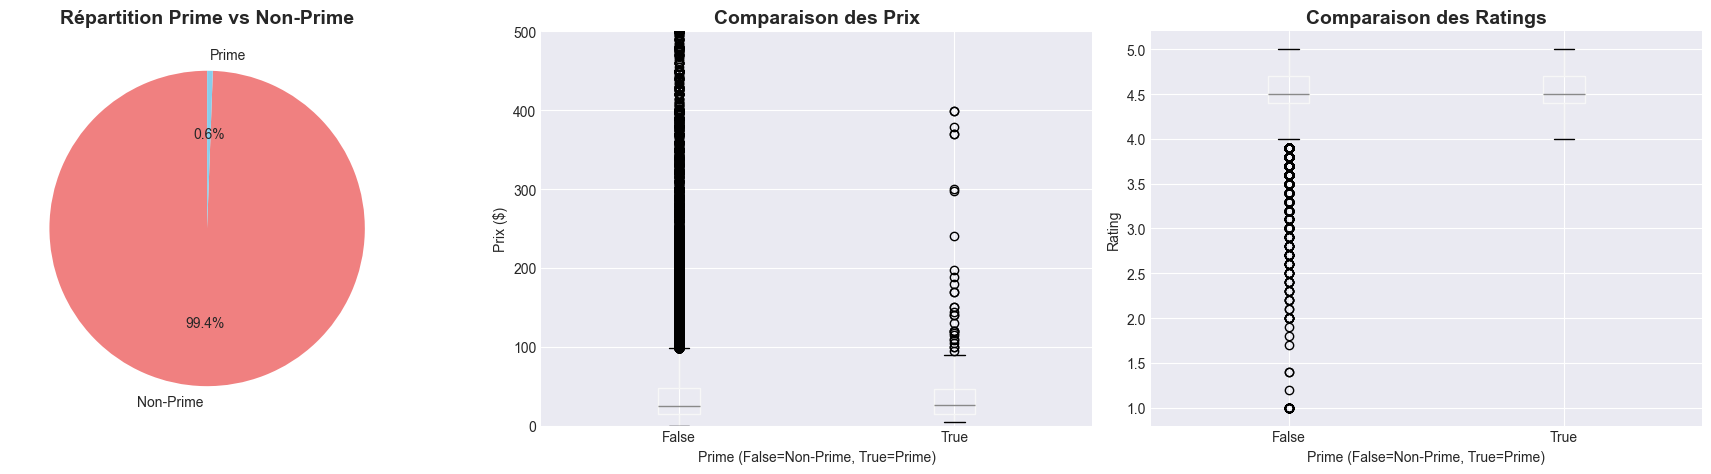

In [ ]:
# Visualisation Prime vs Non-Prime
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Répartition Prime/Non-Prime
prime_counts = df['isPrime'].value_counts()
axes[0].pie(prime_counts.values, labels=['Non-Prime', 'Prime'], autopct='%1.1f%%', 
            colors=['lightcoral', 'skyblue'], startangle=90)
axes[0].set_title('Répartition Prime vs Non-Prime', fontsize=14, fontweight='bold')

# Comparaison des prix
df.boxplot(column='price_numeric', by='isPrime', ax=axes[1])
axes[1].set_title('Comparaison des Prix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prime (False=Non-Prime, True=Prime)')
axes[1].set_ylabel('Prix ($)')
axes[1].set_ylim(0, 500)
plt.suptitle('')

# Comparaison des ratings
df.boxplot(column='rating', by='isPrime', ax=axes[2])
axes[2].set_title('Comparaison des Ratings', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Prime (False=Non-Prime, True=Prime)')
axes[2].set_ylabel('Rating')
plt.suptitle('')

plt.tight_layout()
plt.show()

---
## 7. Analyse des Catégories de Produits 🏷️

In [ ]:
# Extraction des catégories à partir des titres
print("🏷️ EXTRACTION DES CATÉGORIES DE PRODUITS...\n")

# Mots-clés pour identifier les catégories
def categorize_product(title):
    title_lower = str(title).lower()
    
    if any(word in title_lower for word in ['laptop', 'computer', 'pc', 'macbook']):
        return 'Laptops & Computers'
    elif any(word in title_lower for word in ['phone', 'smartphone', 'iphone', 'galaxy', 'pixel']):
        return 'Phones'
    elif any(word in title_lower for word in ['tv', 'television', 'screen', 'display']):
        return 'TVs & Displays'
    elif any(word in title_lower for word in ['headphone', 'earbuds', 'airpods', 'earphone']):
        return 'Audio'
    elif any(word in title_lower for word in ['camera', 'photo', 'video']):
        return 'Cameras'
    elif any(word in title_lower for word in ['furniture', 'table', 'chair', 'desk', 'sofa', 'bed']):
        return 'Furniture'
    elif any(word in title_lower for word in ['charger', 'cable', 'power', 'battery']):
        return 'Accessories'
    else:
        return 'Other'

df['category'] = df['title'].apply(categorize_product)

# Statistiques par catégorie
category_stats = df.groupby('category').agg({
    'asin': 'count',
    'price_numeric': 'mean',
    'rating': 'mean',
    'reviews_count': 'mean'
}).round(2)

category_stats.columns = ['Nombre de Produits', 'Prix Moyen ($)', 'Rating Moyen', 'Reviews Moyen']
category_stats = category_stats.sort_values('Nombre de Produits', ascending=False)
print(category_stats)

🏷️ EXTRACTION DES CATÉGORIES DE PRODUITS...

                     Nombre de Produits  Prix Moyen ($)  Rating Moyen  \
category                                                                
Other                             33817           71.65          4.50   
Furniture                          9194           82.69          4.45   
Laptops & Computers                3597           58.65          4.48   
TVs & Displays                     1466           92.57          4.46   
Accessories                        1323          101.99          4.46   
Phones                              718          125.17          4.43   
Cameras                             314          361.55          4.43   
Audio                                15           91.75          4.15   

                     Reviews Moyen  
category                            
Other                      5133.61  
Furniture                  4046.78  
Laptops & Computers        3720.11  
TVs & Displays             4647.29  
Ac

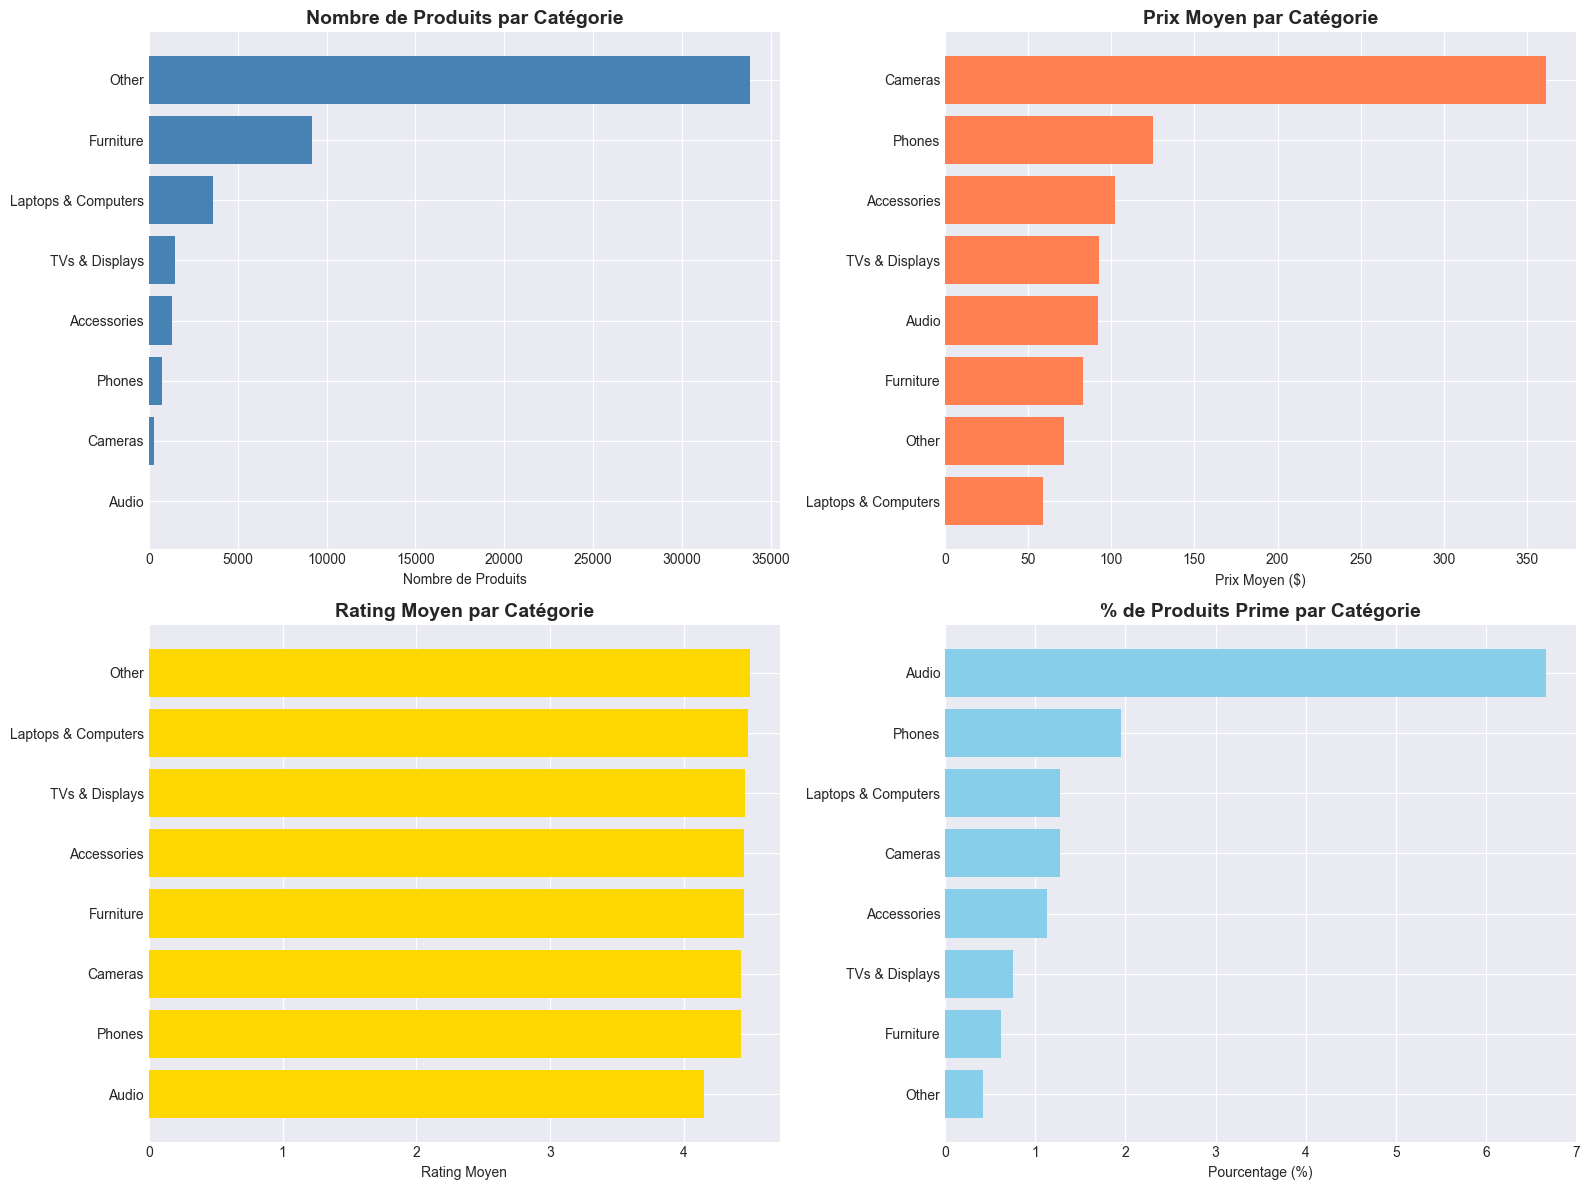

In [ ]:
# Visualisation des catégories
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Nombre de produits par catégorie
category_counts = df['category'].value_counts()
axes[0, 0].barh(range(len(category_counts)), category_counts.values, color='steelblue')
axes[0, 0].set_yticks(range(len(category_counts)))
axes[0, 0].set_yticklabels(category_counts.index)
axes[0, 0].set_title('Nombre de Produits par Catégorie', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Nombre de Produits')
axes[0, 0].invert_yaxis()

# Prix moyen par catégorie
avg_price_by_cat = df.groupby('category')['price_numeric'].mean().sort_values(ascending=False)
axes[0, 1].barh(range(len(avg_price_by_cat)), avg_price_by_cat.values, color='coral')
axes[0, 1].set_yticks(range(len(avg_price_by_cat)))
axes[0, 1].set_yticklabels(avg_price_by_cat.index)
axes[0, 1].set_title('Prix Moyen par Catégorie', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Prix Moyen ($)')
axes[0, 1].invert_yaxis()

# Rating moyen par catégorie
avg_rating_by_cat = df.groupby('category')['rating'].mean().sort_values(ascending=False)
axes[1, 0].barh(range(len(avg_rating_by_cat)), avg_rating_by_cat.values, color='gold')
axes[1, 0].set_yticks(range(len(avg_rating_by_cat)))
axes[1, 0].set_yticklabels(avg_rating_by_cat.index)
axes[1, 0].set_title('Rating Moyen par Catégorie', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Rating Moyen')
axes[1, 0].invert_yaxis()

# Distribution Prime par catégorie
prime_by_cat = df.groupby('category')['isPrime'].mean() * 100
prime_by_cat = prime_by_cat.sort_values(ascending=False)
axes[1, 1].barh(range(len(prime_by_cat)), prime_by_cat.values, color='skyblue')
axes[1, 1].set_yticks(range(len(prime_by_cat)))
axes[1, 1].set_yticklabels(prime_by_cat.index)
axes[1, 1].set_title('% de Produits Prime par Catégorie', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Pourcentage (%)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 8. Visualisations Avancées 📈

📅 ANALYSE TEMPORELLE:



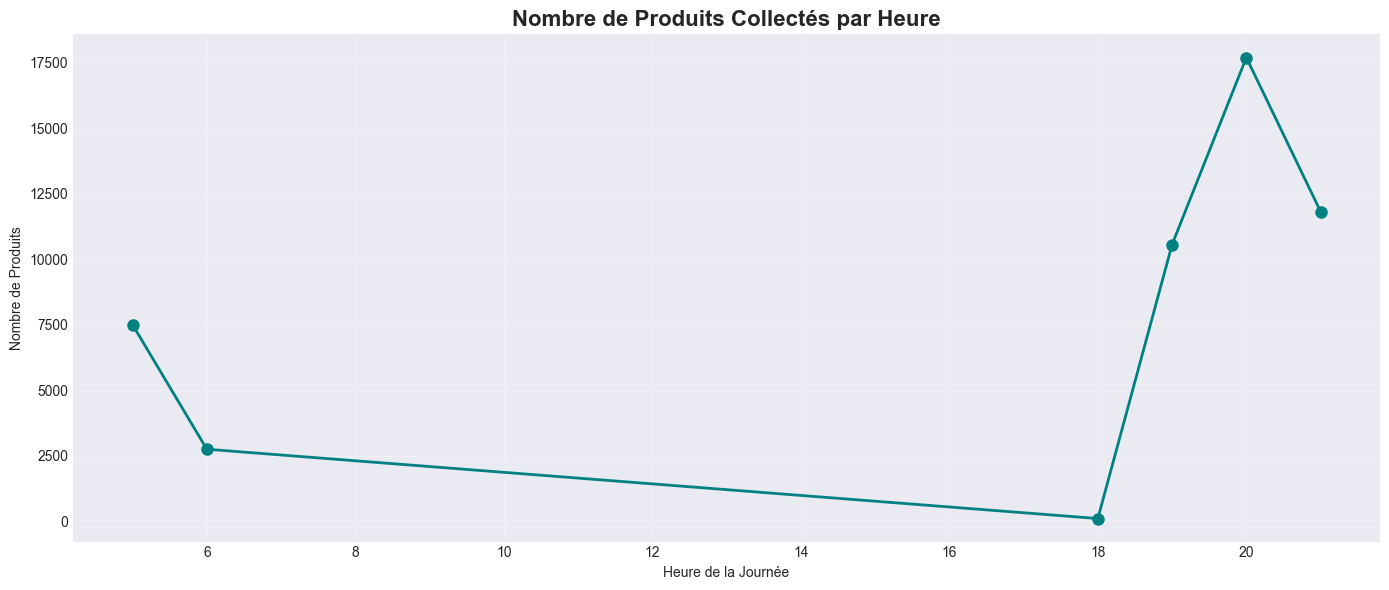

In [ ]:
# Analyse temporelle
print("📅 ANALYSE TEMPORELLE:\n")

# Produits collectés par heure
hourly_collection = df.groupby('hour').size()

plt.figure(figsize=(14, 6))
plt.plot(hourly_collection.index, hourly_collection.values, marker='o', linewidth=2, markersize=8, color='teal')
plt.title('Nombre de Produits Collectés par Heure', fontsize=16, fontweight='bold')
plt.xlabel('Heure de la Journée')
plt.ylabel('Nombre de Produits')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

🛒 TOP 20 PRODUITS LES PLUS ACHETÉS LE MOIS DERNIER:



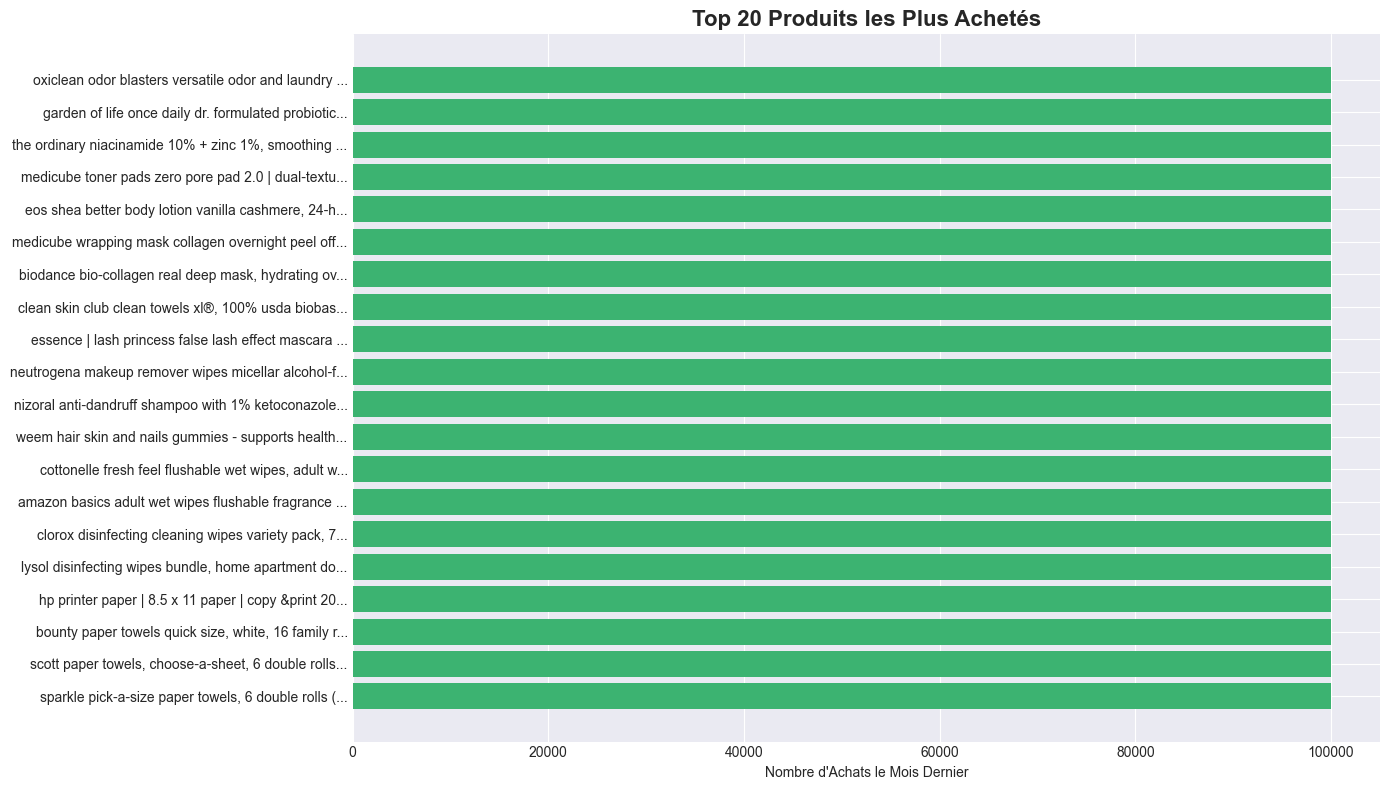

,title,bought_last_month,price_numeric,rating
1942,oxiclean odor blasters versatile odor and laun...,100000,11.78,4.80
2028,garden of life once daily dr. formulated probi...,100000,29.73,4.60
3374,"the ordinary niacinamide 10% + zinc 1%, smooth...",100000,6.00,4.70
3378,medicube toner pads zero pore pad 2.0 | dual-t...,100000,18.90,4.60
3385,"eos shea better body lotion vanilla cashmere, ...",100000,9.97,4.70
3388,medicube wrapping mask collagen overnight peel...,100000,19.00,4.50
3391,"biodance bio-collagen real deep mask, hydratin...",100000,19.00,4.50
3420,"clean skin club clean towels xl®, 100% usda bi...",100000,17.95,4.80
3480,essence | lash princess false lash effect masc...,100000,4.97,4.30
3532,neutrogena makeup remover wipes micellar alcoh...,100000,9.97,4.80


In [ ]:
# Analyse des produits les plus achetés
print("🛒 TOP 20 PRODUITS LES PLUS ACHETÉS LE MOIS DERNIER:\n")

top_bought = df[df['bought_last_month'].notna()].nlargest(20, 'bought_last_month')[['title', 'bought_last_month', 'price_numeric', 'rating']]

plt.figure(figsize=(14, 8))
plt.barh(range(len(top_bought)), top_bought['bought_last_month'].values, color='mediumseagreen')
plt.yticks(range(len(top_bought)), [title[:50] + '...' if len(title) > 50 else title for title in top_bought['title']])
plt.xlabel('Nombre d\'Achats le Mois Dernier')
plt.title('Top 20 Produits les Plus Achetés', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_bought

In [ ]:
# Analyse du rapport qualité-prix
print("💎 ANALYSE DU RAPPORT QUALITÉ-PRIX:\n")

# Créer un score qualité-prix (rating / log(price))
df['value_score'] = df['rating'] / np.log1p(df['price_numeric'])

# Top 20 meilleurs rapports qualité-prix
best_value = df[df['reviews_count'] >= 100].nlargest(20, 'value_score')[['title', 'price_numeric', 'rating', 'reviews_count', 'value_score']]

print("🏆 TOP 20 MEILLEURS RAPPORTS QUALITÉ-PRIX (min 100 reviews):\n")
best_value.index = range(1, 21)
best_value

💎 ANALYSE DU RAPPORT QUALITÉ-PRIX:

🏆 TOP 20 MEILLEURS RAPPORTS QUALITÉ-PRIX (min 100 reviews):



,title,price_numeric,rating,reviews_count,value_score
1,curtain: poirot's last case: a hercule poirot ...,0.00,4.50,2405,inf
2,"the mirror: the lost bride trilogy, book 2",0.00,4.60,23489,inf
3,the mirror,0.00,4.20,2252,inf
4,"mind mapping: improve memory, concentration, c...",0.00,4.40,1209,inf
5,organizing for the rest of us: 100 realistic s...,0.00,4.70,1753,inf
6,organize tomorrow today: 8 ways to retrain you...,0.00,4.60,815,inf
7,organization hacks: over 350 simple solutions ...,0.00,4.00,307,inf
8,the investors guide to growing wealth in self ...,0.00,4.70,687,inf
9,"the rake: boston belles, book 4",0.00,4.50,13410,inf
10,skincare: the ultimate no-nonsense guide,0.00,4.80,12654,inf


---
## 9. Insights et Recommandations 💡

In [ ]:
# Génération du rapport final
print("="*80)
print("📊 RAPPORT D'ANALYSE - INSIGHTS CLÉS")
print("="*80)

print("\n🎯 INSIGHTS PRINCIPAUX:\n")

print("1. DISTRIBUTION DES PRIX:")
print(f"   • Le prix moyen est de ${df['price_numeric'].mean():.2f}")
print(f"   • 50% des produits coûtent moins de ${df['price_numeric'].median():.2f}")
print(f"   • Les prix varient de ${df['price_numeric'].min():.2f} à ${df['price_numeric'].max():.2f}")

print("\n2. QUALITÉ DES PRODUITS:")
print(f"   • Rating moyen: {df['rating'].mean():.2f}/5")
print(f"   • {(df['rating'] >= 4.0).sum()/len(df)*100:.1f}% des produits ont un rating ≥ 4.0")
print(f"   • Nombre moyen de reviews: {df['reviews_count'].mean():,.0f}")

print("\n3. PROGRAMME PRIME:")
prime_pct = df['isPrime'].sum()/len(df)*100
print(f"   • {prime_pct:.1f}% des produits sont éligibles Prime")
prime_avg_price = df[df['isPrime'] == True]['price_numeric'].mean()
non_prime_avg_price = df[df['isPrime'] == False]['price_numeric'].mean()
print(f"   • Prix moyen Prime: ${prime_avg_price:.2f}")
print(f"   • Prix moyen Non-Prime: ${non_prime_avg_price:.2f}")

print("\n4. CATÉGORIES POPULAIRES:")
top_categories = df['category'].value_counts().head(3)
for i, (cat, count) in enumerate(top_categories.items(), 1):
    print(f"   {i}. {cat}: {count:,} produits ({count/len(df)*100:.1f}%)")

print("\n5. PRODUITS À FORT POTENTIEL:")
high_potential = df[(df['rating'] >= 4.5) & (df['reviews_count'] >= 1000) & (df['price_numeric'] < 100)]
print(f"   • {len(high_potential)} produits avec rating ≥ 4.5, ≥ 1000 reviews et prix < $100")

print("\n" + "="*80)
print("📌 RECOMMANDATIONS STRATÉGIQUES")
print("="*80)

print("\n1. OPTIMISATION DES PRIX:")
print("   • Concentrer les efforts sur la gamme $50-$200 (segment le plus populaire)")
print("   • Surveiller les produits Prime pour ajuster les stratégies de pricing")

print("\n2. AMÉLIORATION DE LA QUALITÉ:")
print("   • Prioriser les produits avec peu de reviews mais bon rating")
print("   • Encourager les reviews pour augmenter la visibilité")

print("\n3. GESTION DU CATALOGUE:")
print("   • Développer les catégories à forte demande")
print("   • Analyser les produits à faible performance pour optimisation ou retrait")

print("\n4. STRATÉGIE PRIME:")
print("   • Augmenter l'offre Prime dans les catégories à forte demande")
print("   • Analyser l'impact Prime sur les ventes et la satisfaction client")

print("\n" + "="*80)

📊 RAPPORT D'ANALYSE - INSIGHTS CLÉS

🎯 INSIGHTS PRINCIPAUX:

1. DISTRIBUTION DES PRIX:
   • Le prix moyen est de $76.71
   • 50% des produits coûtent moins de $24.99
   • Les prix varient de $0.00 à $399800.00

2. QUALITÉ DES PRODUITS:


   • Rating moyen: 4.48/5
   • 95.8% des produits ont un rating ≥ 4.0
   • Nombre moyen de reviews: 4,929

3. PROGRAMME PRIME:
   • 0.6% des produits sont éligibles Prime
   • Prix moyen Prime: $47.19
   • Prix moyen Non-Prime: $76.89

4. CATÉGORIES POPULAIRES:
   1. Other: 33,817 produits (67.0%)
   2. Furniture: 9,194 produits (18.2%)
   3. Laptops & Computers: 3,597 produits (7.1%)

5. PRODUITS À FORT POTENTIEL:
   • 14621 produits avec rating ≥ 4.5, ≥ 1000 reviews et prix < $100

📌 RECOMMANDATIONS STRATÉGIQUES

1. OPTIMISATION DES PRIX:
   • Concentrer les efforts sur la gamme $50-$200 (segment le plus populaire)
   • Surveiller les produits Prime pour ajuster les stratégies de pricing

2. AMÉLIORATION DE LA QUALITÉ:
   • Prioriser les produits avec peu de reviews mais bon rating
   • Encourager les reviews pour augmenter la visibilité

3. GESTION DU CATALOGUE:
   • Développer les catégories à forte demande
   • Analyser les produits à faible performance pour optimisation ou retrai

In [ ]:
# Export des résultats
print("\n💾 EXPORT DES RÉSULTATS...\n")

# Créer un résumé pour export
summary_data = {
    'Métrique': [
        'Total Produits',
        'Prix Moyen',
        'Prix Médian',
        'Rating Moyen',
        'Reviews Moyen',
        '% Produits Prime',
        '% Produits Sponsorisés',
        'Catégorie Principale'
    ],
    'Valeur': [
        f"{len(df):,}",
        f"${df['price_numeric'].mean():.2f}",
        f"${df['price_numeric'].median():.2f}",
        f"{df['rating'].mean():.2f}",
        f"{df['reviews_count'].mean():,.0f}",
        f"{df['isPrime'].sum()/len(df)*100:.1f}%",
        f"{df['sponsoredAd'].sum()/len(df)*100:.1f}%",
        df['category'].value_counts().index[0]
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('amazon_analysis_summary.csv', index=False)
print("✅ Résumé exporté vers: amazon_analysis_summary.csv")

# Export des données enrichies
df.to_csv('amazon_data_enriched.csv', index=False)
print("✅ Données enrichies exportées vers: amazon_data_enriched.csv")

print("\n🎉 ANALYSE TERMINÉE AVEC SUCCÈS!")


💾 EXPORT DES RÉSULTATS...

✅ Résumé exporté vers: amazon_analysis_summary.csv
✅ Données enrichies exportées vers: amazon_data_enriched.csv

🎉 ANALYSE TERMINÉE AVEC SUCCÈS!


---
## 📝 Notes pour l'Équipe Data Analysis

### Points d'Attention:
- Les données contiennent quelques valeurs manquantes - vérifier la qualité des données
- Certains prix semblent aberrants - envisager un nettoyage supplémentaire
- La distribution des prix est très asymétrique - utiliser la médiane plutôt que la moyenne

### Prochaines Étapes:
1. Analyse de sentiment sur les titres de produits
2. Modèle prédictif pour estimer les ventes
3. Segmentation des clients/produits
4. Analyse de la concurrence par catégorie

### Ressources:
- Dataset original: `amazon_final.csv`
- Dataset enrichi: `amazon_data_enriched.csv`
- Résumé: `amazon_analysis_summary.csv`

---
*Notebook créé le 2026-02-10 | Version 1.0*